Fresh-kernel validation of dependency helpers and the appended neuro-symbolic section.

In [1]:
import math, os, random, sys, time, json
from pathlib import Path
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython import display
torch.set_num_threads(4)
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False


In [2]:
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def try_all_gpus():
    """返回所有可用的GPU，如果没有GPU，则返回[cpu(),]"""
    devices = [torch.device(f'cuda:{i}')
               for i in range(torch.cuda.device_count())]
    return devices if devices else [torch.device('cpu')]

class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def use_svg_display():
    """使用svg格式在Jupyter中显示图像"""
    try:
        from matplotlib_inline import backend_inline
        backend_inline.set_matplotlib_formats('svg')
    except Exception:
        pass

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim:
        axes.set_xlim(xlim)
    if ylim:
        axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        """向图表中添加多个数据点"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x_arr, y_arr, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x_arr, y_arr, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

def tokenize(lines, token='word'):
    """将文本行拆分为单词或字符词元"""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知词元类型：' + token)

def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def set_figsize(figsize=(3.5, 2.5)):
    """设置 matplotlib 的图表大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, (list, tuple)):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, (list, tuple)):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    return l.sum().detach(), accuracy(pred.detach(), y)

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices=None):
    if devices is None:
        devices = try_all_gpus()
    if isinstance(devices, torch.device):
        devices = [devices]
    if len(devices) > 1 and all(d.type == 'cuda' for d in devices):
        net = nn.DataParallel(net, device_ids=devices)
    net = net.to(devices[0])
    timer, num_batches = Timer(), len(train_iter)
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % max(1, num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3], None))
        test_acc = evaluate_accuracy_gpu(net, test_iter, devices[0])
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc {metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}')

def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def set_figsize(figsize=(3.5, 2.5)):
    """设置matplotlib的图表大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def mlp(num_inputs, num_hiddens, flatten):
    net = []
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)

class Attend(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Attend, self).__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        # A/B的形状：（批量大小，序列A/B的词元数，embed_size）
        # f_A/f_B的形状：（批量大小，序列A/B的词元数，num_hiddens）
        f_A = self.f(A)
        f_B = self.f(B)
        # e的形状：（批量大小，序列A的词元数，序列B的词元数）
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))
        # beta的形状：（批量大小，序列A的词元数，embed_size），
        # 意味着序列B被软对齐到序列A的每个词元(beta的第1个维度)
        beta = torch.bmm(F.softmax(e, dim=-1), B)
        # beta的形状：（批量大小，序列B的词元数，embed_size），
        # 意味着序列A被软对齐到序列B的每个词元(alpha的第1个维度)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)
        return beta, alpha

class Compare(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Compare, self).__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        V_A = self.g(torch.cat([A, beta], dim=2))
        V_B = self.g(torch.cat([B, alpha], dim=2))
        return V_A, V_B

class Aggregate(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super(Aggregate, self).__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = nn.Linear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        # 对两组比较向量分别求和
        V_A = V_A.sum(dim=1)
        V_B = V_B.sum(dim=1)
        # 将两个求和结果的连结送到多层感知机中
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat

class DecomposableAttention(nn.Module):
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super(DecomposableAttention, self).__init__(**kwargs)
        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        # 有3种可能的输出：蕴涵、矛盾和中性
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)

    def forward(self, X):
        premises, hypotheses = X
        A = self.embedding(premises)
        B = self.embedding(hypotheses)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        Y_hat = self.aggregate(V_A, V_B)
        return Y_hat

def train_batch_ch13(net, X, y, loss, trainer, devices):
    """用多GPU进行小批量训练（同时支持单输入和多输入 list/tuple）"""
    if isinstance(X, (list, tuple)):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    return l.sum().detach(), accuracy(pred.detach(), y)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """在指定设备上评估精度（同时支持单输入和多输入）"""
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, (list, tuple)):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=None):
    """用多GPU进行模型训练"""
    if devices is None:
        devices = try_all_gpus()
    if isinstance(devices, torch.device):
        devices = [devices]
    if len(devices) > 1 and all(d.type == 'cuda' for d in devices):
        net = nn.DataParallel(net, device_ids=devices)
    net = net.to(devices[0])
    timer, num_batches = Timer(), len(train_iter)
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            # 使用 labels.shape[0] 作为样本量，彻底解决 features 是 list 导致的 AttributeError
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % max(1, num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3], None))
        test_acc = evaluate_accuracy_gpu(net, test_iter, devices[0])
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc {metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}')

loss 1.143, train acc 0.125, test acc 0.875
19.9 examples/sec on [device(type='cpu')]
Dependency smoke passed: real SNLI sentence pairs, list inputs, training and evaluation.


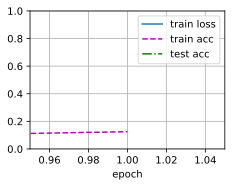

In [3]:

assert tokenize(['a  b', 'c\td']) == [['a', 'b'], ['c', 'd']]
assert tokenize(['ab'], token='char') == [['a', 'b']]
assert truncate_pad([1, 2, 3], 2, 0) == [1, 2]
assert truncate_pad([1], 3, 0) == [1, 0, 0]
from experiments.neurosymbolic_nli.data import load_data
_check_run = Path('runs/neurosymbolic_nli/20260915_order_v1')
_check_data = load_data(_check_run)
_check_split = _check_data['splits']['train']
class _CheckSNLI(torch.utils.data.Dataset):
    def __len__(self): return 8
    def __getitem__(self, i):
        return (_check_split['premises'][i, :12], _check_split['hypotheses'][i, :12]), _check_split['labels'][i]
_check_loader = torch.utils.data.DataLoader(_CheckSNLI(), batch_size=4)
_check_net = DecomposableAttention(_check_data['vocab'], 100, 32, num_inputs_agg=64)
_check_trainer = torch.optim.Adam(_check_net.parameters(), lr=.001)
_check_before = _check_net.aggregate.linear.weight.detach().clone()
train_ch13(_check_net, _check_loader, _check_loader, nn.CrossEntropyLoss(reduction='none'),
           _check_trainer, 1, [torch.device('cpu')])
assert not torch.equal(_check_before, _check_net.aggregate.linear.weight)
assert all(torch.isfinite(p).all() for p in _check_net.parameters())
_check_acc = evaluate_accuracy_gpu(_check_net, _check_loader, torch.device('cpu'))
assert 0 <= _check_acc <= 1
(_check_run / 'dependency_smoke.json').write_text(json.dumps({
    'passed': True, 'tokenize_word_char': True, 'truncate_pad': True,
    'actual_snli_pairs': 8, 'multi_input_training_batches': 2,
    'weights_updated': True, 'finite_model': True, 'accuracy': _check_acc,
    'scope': 'current notebook helper definitions and original DecomposableAttention; not a quality estimate'
}, indent=2) + '\n', encoding='utf-8')
print('Dependency smoke passed: real SNLI sentence pairs, list inputs, training and evaluation.')


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 序嵌入网络：将自然语言映射到非负偏序空间 R_+^d
class OrderEmbeddingNLI(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, poset_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # 特征提取 Encoder (此处用 GRU 提取时序语义)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        # 投影至偏序空间，并通过 ReLU 强制落在非负象限 R_+^d
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, poset_dim),
            nn.ReLU()
        )

    def encode(self, x):
        embeds = self.embedding(x)
        _, h_n = self.encoder(embeds)
        # 映射到非负偏序锥中
        poset_vec = self.proj(h_n.squeeze(0))
        return poset_vec

    @staticmethod
    def energy(u, v):
        """
        计算离散偏序违背程度:
        若 u 蕴涵 v，则要求每个维度 u_k >= v_k，违背量 max(0, v - u) 应为 0
        """
        violation = torch.relu(v - u)
        return torch.sum(violation ** 2, dim=-1)

# 2. 偏序约束损失函数 (Max-Margin Order Loss)
class OrderLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, pos_u, pos_v, neg_u, neg_v):
        # 正样本对 (蕴涵): 违序能量趋向于 0
        loss_pos = OrderEmbeddingNLI.energy(pos_u, pos_v)
        # 负样本对 (不蕴涵/矛盾): 违序能量应至少大于预设间隔 margin
        loss_neg = torch.relu(self.margin - OrderEmbeddingNLI.energy(neg_u, neg_v))
        return (loss_pos + loss_neg).mean()



def run_order_embedding_toy(seed=17):
    """Run the original toy locally without overwriting SNLI vocab/model."""
    with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
        torch.manual_seed(seed)
        # 词表构建
        vocab = {"<pad>": 0, "a": 1, "small": 2, "terrier": 3, "dog": 4, 
                 "animal": 5, "barking": 6, "running": 7}

        # 构造蕴涵链样本: A -> B, B -> C
        # A: "a small terrier barking"
        # B: "a dog barking"
        # C: "an animal barking"
        # D: "a small terrier running" (非蕴涵样例；running 与 barking 可以同时成立)
        sent_A = torch.tensor([[1, 2, 3, 6]])
        sent_B = torch.tensor([[1, 4, 6, 0]])
        sent_C = torch.tensor([[1, 5, 6, 0]])
        sent_D = torch.tensor([[1, 2, 3, 7]])

        model = OrderEmbeddingNLI(vocab_size=len(vocab), embed_dim=16, hidden_dim=32, poset_dim=16)
        criterion = OrderLoss(margin=1.0)
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        print("=== 开始注入偏序关系并训练 ===")
        # 仅向模型训练 A -> B 和 B -> C，绝不给模型喂 A -> C
        for epoch in range(150):
            optimizer.zero_grad()
            u_A = model.encode(sent_A)
            v_B = model.encode(sent_B)
            v_C = model.encode(sent_C)
            v_D = model.encode(sent_D)

            # 批次包含: 正样本 (A->B), (B->C); 负样本 (B->A 非对称), (A->D 非蕴涵)
            loss1 = criterion(u_A, v_B, v_B, u_A) # 正: A->B, 负: B->A
            loss2 = criterion(v_B, v_C, u_A, v_D) # 正: B->C, 负: A->D
            loss = loss1 + loss2
    
            loss.backward()
            optimizer.step()

        print(f"训练收敛 Loss: {loss.item():.4f}\n")

        # 4. 验证离散数学性质
        model.eval()
        with torch.no_grad():
            u_A = model.encode(sent_A)
            v_B = model.encode(sent_B)
            v_C = model.encode(sent_C)

            e_AB = OrderEmbeddingNLI.energy(u_A, v_B).item()
            e_BC = OrderEmbeddingNLI.energy(v_B, v_C).item()
            e_AC = OrderEmbeddingNLI.energy(u_A, v_C).item()  # 已见句子的未训练边推断
            e_BA = OrderEmbeddingNLI.energy(v_B, u_A).item()  # 指定逆向边检验

        print("=== 离散数学性质推断验证 ===")
        print(f"1. 前提 A 蕴涵 B 能量 (目标 ~0): {e_AB:.4f}")
        print(f"2. 前提 B 蕴涵 C 能量 (目标 ~0): {e_BC:.4f}")
        print(f"3. [传递性检验] A 蕴涵 C 能量 (未训练边，句子均已见): {e_AC:.4f}")
        print(f"4. [指定逆向边检验] B 蕴涵 A 能量 (目标 >= 1.0): {e_BA:.4f}")

        # 判定
        is_transitive = e_AB < 0.05 and e_BC < 0.05 and e_AC < 0.05
        is_asymmetric = e_BA > 0.8
        print(f"\n当前链 AB、BC、AC 是否均满足阈值（非全局证明）: {'通过' if is_transitive else '未通过'}")
        print(f"指定逆向边 B->A 是否被拒绝（非反对称律证明）: {'通过' if is_asymmetric else '未通过'}")
        return {"AB": e_AB, "BC": e_BC, "AC": e_AC, "BA": e_BA, "chain_threshold_check": is_transitive, "reverse_edge_rejected": is_asymmetric, "scope": "seen sentences, held-out edge only"}


toy_order_result = run_order_embedding_toy()


=== 开始注入偏序关系并训练 ===


训练收敛 Loss: 0.0000

=== 离散数学性质推断验证 ===
1. 前提 A 蕴涵 B 能量 (目标 ~0): 0.0000
2. 前提 B 蕴涵 C 能量 (目标 ~0): 0.0000
3. [传递性检验] A 蕴涵 C 能量 (未训练边，句子均已见): 0.0000
4. [指定逆向边检验] B 蕴涵 A 能量 (目标 >= 1.0): 24.8656

当前链 AB、BC、AC 是否均满足阈值（非全局证明）: 通过
指定逆向边 B->A 是否被拒绝（非反对称律证明）: 通过


## 续作：GRU、偏序约束与离散图推理的可验证实验

本节接续上面的四句 `OrderEmbeddingNLI` 演示，使用真实 SNLI 三分类进行配对验证。这里的任务是**自然语言蕴涵识别**，不是干预效应估计。

改进包括有效长度编码、正值序投影、三分类监督、偏序辅助损失，以及可追踪的离散图闭包。对照模型与偏序模型使用同一结构，唯一实验变量是辅助损失权重。下面直接加载已经完成的结果，不会启动大规模训练。

In [5]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

nli_project = Path.cwd()
assert (nli_project / 'experiments/neurosymbolic_nli/model.py').is_file(), '请从项目根目录打开此笔记本'
nli_run = nli_project / 'runs/neurosymbolic_nli/20260915_order_v1'
nli_summary = json.loads((nli_run / 'summary.json').read_text(encoding='utf-8'))
nli_verification = json.loads((nli_run / 'verification.json').read_text(encoding='utf-8'))
assert nli_verification['all_passed']
print('六次最终训练与逐样本核查已完成。')
print('训练/开发/测试：60,000 / 9,842 / 9,824；固定种子：17, 29, 43。')

六次最终训练与逐样本核查已完成。
训练/开发/测试：60,000 / 9,842 / 9,824；固定种子：17, 29, 43。


### 方法与数学边界

沿用 GRU 编码，但用 `pack_padded_sequence` 排除 padding；序投影用 Softplus，不做单位 L2 归一化。三分类头保留 entailment / contradiction / neutral。

\[
E(P,H)=\frac1d\sum_k\max(0,z_{H,k}-z_{P,k})^2,
\quad L=L_{CE}+\lambda\,\mathbb{E}[\mathbf{1}_{y=E}E(P,H)+\mathbf{1}_{y\ne E}\max(0,m-E(P,H))].
\]

两组使用相同初始化、训练样本顺序和最终训练轮数，分别取 $\lambda=0$ 与 $0.2$，$m=0.2$。不自动把反向蕴涵标为负例。精确坐标序的传递性不能推广为任意正阈值的分类保证；序损失也不能替代自然语言测试集。

In [6]:
from experiments.neurosymbolic_nli.model import NeuralOrderNLI, order_penalty
import inspect
print(inspect.getsource(NeuralOrderNLI))
print(inspect.getsource(order_penalty))

class NeuralOrderNLI(nn.Module):
    def __init__(self, embeddings, hidden_dim=128, order_dim=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embeddings.clone(), freeze=False, padding_idx=0)
        self.encoder = nn.GRU(embeddings.shape[1], hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.order_projection = nn.Sequential(
            nn.Linear(hidden_dim, order_dim), nn.Softplus())
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4 + 2, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, 3))

    def encode(self, tokens, lengths):
        embeddings = self.dropout(self.embedding(tokens))
        packed = pack_padded_sequence(
            embeddings, lengths.detach().cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.encoder(packed)
        hidden = hidden[-1]
        return hidden, self.order_projection(hidden)


In [7]:
from experiments.neurosymbolic_nli.logic_audit import run_logic_audit
nli_logic = run_logic_audit(nli_run)
assert nli_logic['all_passed']
display(pd.DataFrame({'check': list(nli_logic['checks']), 'passed': list(nli_logic['checks'].values())}))
print('非零阈值反例：', nli_logic['threshold_counterexample'])
print('已知边上的离散推理路径：', nli_logic['held_out_edge_demo'])

,check,passed
0,exact_energy_characterizes_coordinate_order,True
1,exact_reflexivity,True
2,exact_coordinate_antisymmetry,True
3,exact_transitivity,True
4,positive_threshold_transitivity_counterexample,True
5,randomized_directed_triangle_bound,True
6,tight_directed_triangle_bound,True
7,broadcast_autograd_matches_analytic_derivatives,True
8,held_out_edge_is_not_observed,True
9,held_out_edge_has_observed_path_witness,True


非零阈值反例： {'A': [0.0], 'B': [0.2], 'C': [0.4], 'E_AB': 0.04000000000000001, 'E_BC': 0.04000000000000001, 'E_AC': 0.16000000000000003, 'threshold': 0.05, 'decision_rule': 'E(x,y) < threshold', 'conclusion': 'The positive-threshold relation is not transitive.'}
已知边上的离散推理路径： {'edge': ['A', 'C'], 'path_witness': ['A', 'B', 'C'], 'evaluation_type': 'Logical closure of supplied edges over seen node IDs', 'training_performed': False}


,method,seed,test_accuracy_%,test_macro_F1_%
0,neural,17,72.445,72.117
1,order_regularized,17,72.221,71.864
2,neural,29,72.771,72.483
3,order_regularized,29,72.659,72.371
4,neural,43,74.379,74.312
5,order_regularized,43,74.125,74.060


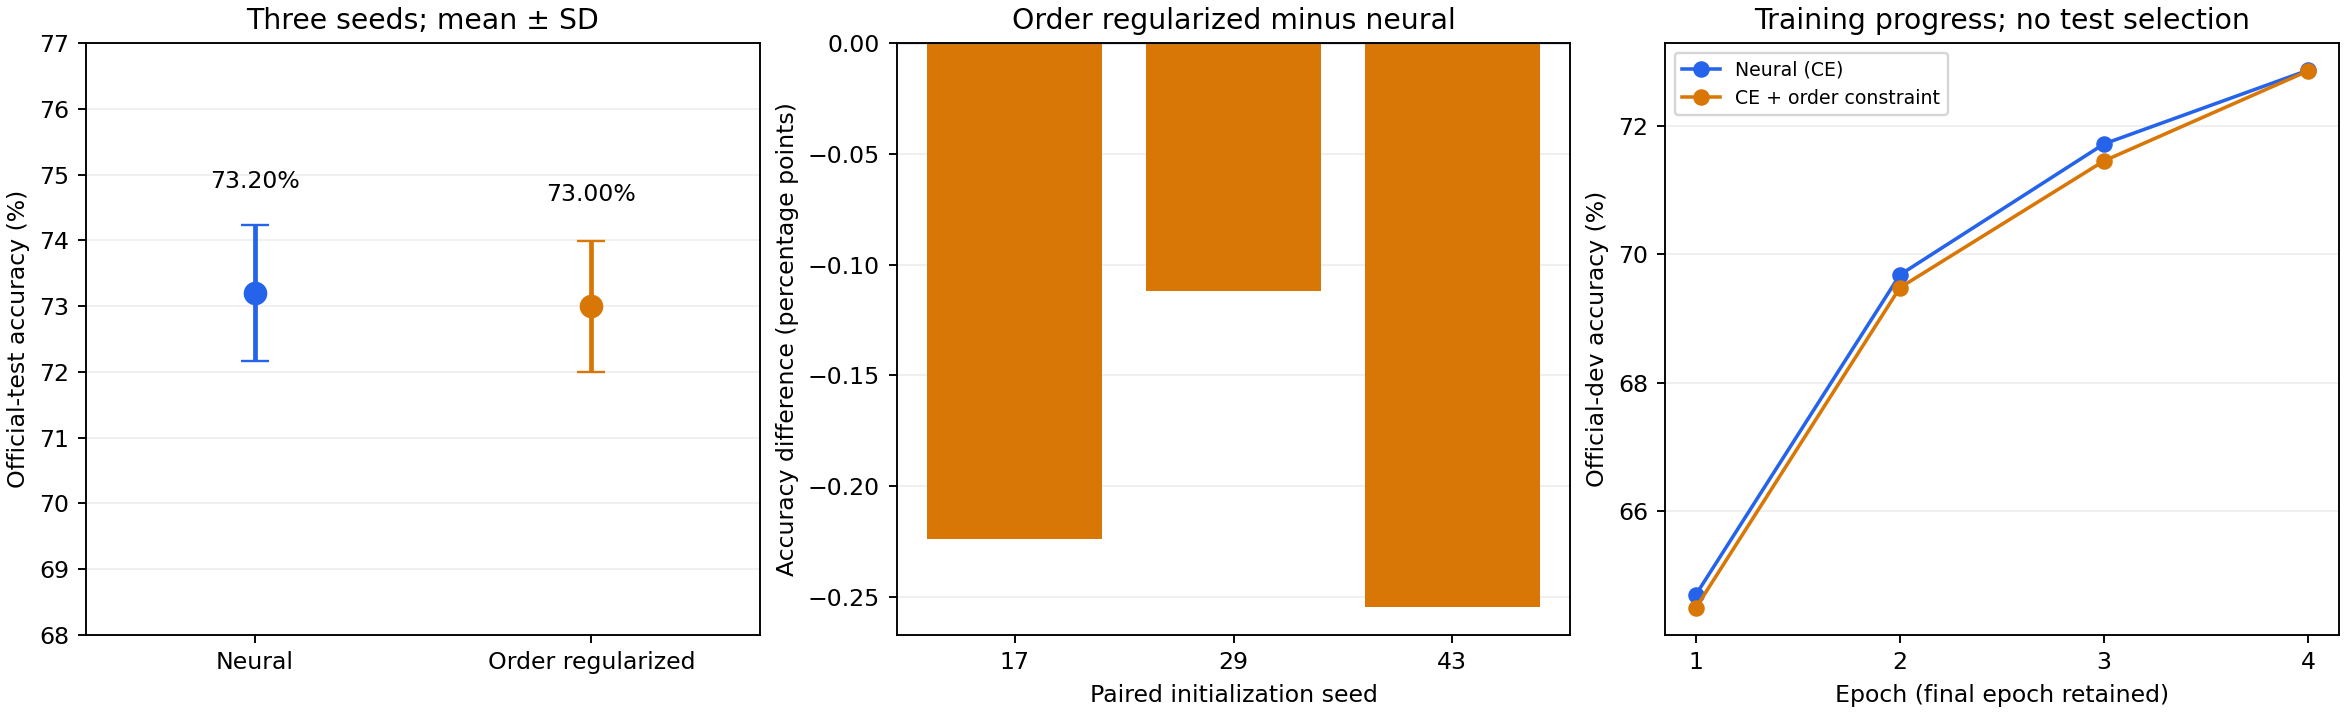

平均准确率差值（偏序组－神经组，百分点）： -0.1967969598262731


In [8]:
nli_rows = [{'method': r['arm'], 'seed': r['seed'],
             'test_accuracy_%': 100 * r['test']['accuracy'],
             'test_macro_F1_%': 100 * r['test']['macro_f1']}
            for r in nli_summary['results']]
display(pd.DataFrame(nli_rows).round(3))
display(Image(filename=str(nli_run / 'snli_comparison.png')))
print('平均准确率差值（偏序组－神经组，百分点）：',
      100 * nli_summary['order_minus_neural_accuracy_mean'])

In [9]:
from experiments.neurosymbolic_nli.inference import predict_pairs
nli_examples = [
    ('A dog is running .', 'An animal is running .'),
    ('A man is sleeping .', 'A man is awake .'),
    ('A person is standing .', 'A person is wearing a hat .'),
]
# 固定第一个种子展示，不按测试集挑选最好种子；以下是模型预测，不是形式证明。
nli_predictions = predict_pairs(nli_run, nli_examples, arm='neural', seed=17, device='cpu')
nli_probe_expected = ['entailment', 'contradiction', 'neutral']
for nli_prediction, nli_expected in zip(nli_predictions, nli_probe_expected):
    nli_prediction['expected_diagnostic_label'] = nli_expected
    nli_prediction['matches_expectation'] = nli_prediction['prediction'] == nli_expected
display(pd.DataFrame(nli_predictions))

,premise,hypothesis,prediction,probabilities,forward_order_energy,reverse_order_energy,arm,seed,expected_diagnostic_label,matches_expectation
0,A dog is running .,An animal is running .,entailment,"{'entailment': 0.9901987314224243, 'contradict...",0.000269,0.015908,neural,17,entailment,True
1,A man is sleeping .,A man is awake .,entailment,"{'entailment': 0.8548814654350281, 'contradict...",0.006125,0.040676,neural,17,contradiction,False
2,A person is standing .,A person is wearing a hat .,entailment,"{'entailment': 0.8612257838249207, 'contradict...",0.000601,0.008392,neural,17,neutral,False


In [10]:
import sys
nli_reproduce_command = [sys.executable,
    str(nli_project / 'experiments/neurosymbolic_nli/run_experiment.py'),
    '--run-dir', str(nli_run)]
print('复现命令：', nli_reproduce_command)
print('完整说明：', nli_run / 'REPORT.md')
print('核查通过项目：', sum(nli_verification['checks'].values()))

复现命令： ['/home/lgd/anaconda3/bin/python', '/mnt/c/Users/lgd/PycharmProjects/JupyterProject1/experiments/neurosymbolic_nli/run_experiment.py', '--run-dir', '/mnt/c/Users/lgd/PycharmProjects/JupyterProject1/runs/neurosymbolic_nli/20260915_order_v1']
完整说明： /mnt/c/Users/lgd/PycharmProjects/JupyterProject1/runs/neurosymbolic_nli/20260915_order_v1/REPORT.md
核查通过项目： 24


本轮偏序正则的平均测试准确率为 73.001%，神经对照为 73.198%，差值 -0.197 个百分点。三个种子均下降，因此本轮不支持“偏序正则提高 SNLI 准确率”的结论。

本轮采用普通神经对照作为默认分类模型，保留偏序模型与离散闭包用于进一步研究。18 项结构核查通过，六次测试预测均独立重算通过；这些结果证明实现与验证可复现，不能证明逻辑约束一定提高自然语言准确率。

原四句示例只留出一条关系边，并未留出句子；“吠叫”与“跑步”也不是逻辑矛盾。严格结构性质、近似阈值行为和真实文本泛化必须分开报告。

诊断样例中仍有明显错误（如 sleeping→awake 被预测为蕴涵），说明模型仍可能依赖词面重叠。这里完整展示失败，模型输出不能视为形式逻辑证明。

依据：[序嵌入原论文](https://arxiv.org/abs/1511.06361)、[SNLI 官方数据说明](https://nlp.stanford.edu/projects/snli/)。